In [47]:
import numpy as np, pandas as pd
from sim_theorem_partii import sin2_angle_to_axis

SEED = 20260717
k = 3

sigma = np.array([0.16, 0.08, 0.06])      # factor vols
c     = np.array([1.25, 1.0, 1.0])         # prevalences
Chalf = np.diag(np.sqrt(c))
n, N_REPS = 63, 100_000
rng = np.random.default_rng(SEED)

sin2 = np.empty((N_REPS, k))
for r in range(N_REPS):
    F = rng.standard_t(6, size=(n, k)) / np.sqrt(1.5) * sigma
    Dhat = Chalf @ (F.T @ F / n) @ Chalf
    vals, vecs = np.linalg.eigh(Dhat)   # ascending
    W = vecs[:, ::-1]                    # reverse columns -> factor 1,2,3
    sin2[r] = sin2_angle_to_axis(W)

q = np.quantile(sin2, [0.50, 0.80, 0.95], axis=0)   # shape (3 quantiles, 3 factors)
pd.DataFrame(q, index=["q50", "q80", "q95"],
                columns=["factor 1", "factor 2", "factor 3"])

,factor 1,factor 2,factor 3
q50,0.004838,0.030781,0.025766
q80,0.012612,0.122750,0.118759
q95,0.027672,0.546264,0.545881


In [48]:
def rotation_sin2_rep(n, rng, dist="t6"):
    if dist == "t6":
        F = rng.standard_t(6, size=(n, k)) / np.sqrt(1.5) * sigma
    else:  # "normal"
        F = rng.standard_normal(size=(n, k)) * sigma
    Dhat = Chalf @ (F.T @ F / n) @ Chalf
    vals, vecs = np.linalg.eigh(Dhat)
    W = vecs[:, ::-1]
    return sin2_angle_to_axis(W)

In [49]:
N_VALUES = [20, 42, 63, 126, 189, 252]   # ~1 month to ~1 year of daily data
q_levels = [0.05, 0.25, 0.50, 0.75, 0.80, 0.95]   # box (q25/q50/q75) + whiskers (q05/q95)

rows = []
for dist in ["t6", "normal"]:
    for nv in N_VALUES:
        rng_n = np.random.default_rng(SEED + nv)
        s = np.array([rotation_sin2_rep(nv, rng_n, dist) for _ in range(N_REPS)])
        for lvl in q_levels:
            qv = np.quantile(s, lvl, axis=0)
            for j in range(k):
                rows.append({"dist": dist, "n": nv, "quantile": lvl,
                             "factor": j+1, "rotation_sin2": qv[j]})

tbl = pd.DataFrame(rows)
tbl.to_csv("nb_outputs/ex4_rotation_quantiles.csv", index=False)
tbl[tbl["quantile"] == 0.95].pivot_table(index=["factor","n"], columns="dist", values="rotation_sin2")

dist          normal        t6
factor n                      
1      20   0.087163  0.129424
       42   0.037296  0.045982
       63   0.023825  0.027791
       126  0.011717  0.012656
       189  0.007689  0.008106
       252  0.005653  0.005969
2      20   0.790887  0.946685
       42   0.407566  0.785657
       63   0.248204  0.550188
       126  0.105545  0.183653
       189  0.067824  0.097789
       252  0.049098  0.064910
3      20   0.787203  0.943396
       42   0.405246  0.782979
       63   0.245563  0.548806
       126  0.104236  0.182607
       189  0.067040  0.097029
       252  0.048408  0.064338

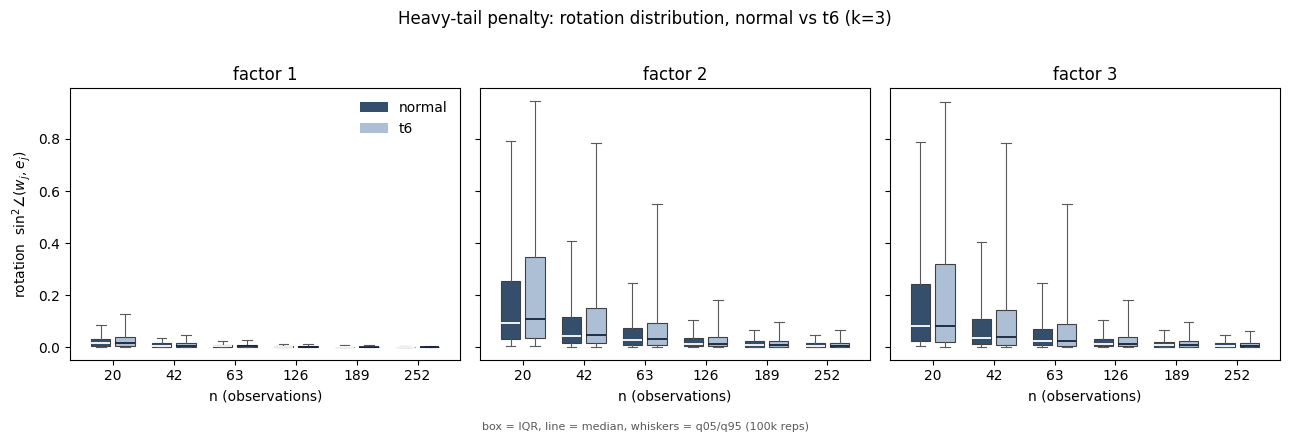

In [50]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
NORMAL, T6 = "#354E6B", "#ACBFD4"

def rotation_bxp(ax, sub_pivot, positions, facecolor, median_color):
    """Boxplot from precomputed quantiles: box = IQR, line = median, whiskers = q05/q95."""
    stats = [{"whislo": sub_pivot.loc[nv, 0.05], "q1": sub_pivot.loc[nv, 0.25],
              "med": sub_pivot.loc[nv, 0.50], "q3": sub_pivot.loc[nv, 0.75],
              "whishi": sub_pivot.loc[nv, 0.95], "fliers": []}
             for nv in sub_pivot.index]
    ax.bxp(stats, positions=positions, widths=0.32, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor=facecolor, edgecolor="0.25", lw=0.8),
           medianprops=dict(color=median_color, lw=1.3),
           whiskerprops=dict(color="0.35", lw=0.8), capprops=dict(color="0.35", lw=0.8))

x = np.arange(len(N_VALUES))
fig, axes = plt.subplots(1, k, figsize=(13, 4), sharey=True)
for ax, j in zip(axes, range(1, k + 1)):
    for dist, fc, off, mc in [("normal", NORMAL, -0.2, "white"), ("t6", T6, 0.2, "#16233A")]:
        sub = (tbl[(tbl["dist"] == dist) & (tbl["factor"] == j)]
               .pivot(index="n", columns="quantile", values="rotation_sin2").loc[N_VALUES])
        rotation_bxp(ax, sub, x + off, fc, mc)
    ax.set_title(f"factor {j}")
    ax.set_xticks(x); ax.set_xticklabels(N_VALUES)
    ax.set_xlabel("n (observations)")
axes[0].set_ylabel(r"rotation  sin$^2\angle(w_j, e_j)$")
axes[0].legend(handles=[Patch(facecolor=NORMAL, label="normal"),
                        Patch(facecolor=T6, label="t6")], frameon=False)
fig.suptitle("Heavy-tail penalty: rotation distribution, normal vs t6 (k=3)", y=1.02)
fig.text(0.5, -0.03, "box = IQR, line = median, whiskers = q05/q95 (100k reps)",
         ha="center", fontsize=8, color="0.35")
fig.tight_layout()
fig.savefig("nb_outputs/ex4_rotation_boxplots.png", dpi=200, bbox_inches="tight")
plt.show()

## Angle-term coefficient: asymptotics in $n$ and $p$

The Part (ii) RHS weights the rotation term by the coefficient
$n\rho_j/(n\rho_j+\delta^2)$ (complement of the floor $\delta^2/(n\rho_j+\delta^2)$).
Structurally, everything $p$-sized in the panel $Y = B^\top F + Z$ is averaged out by
$p\to\infty$ and survives only through deterministic summaries ($Z$ through $\delta^2$,
$B$ through the prevalences $c_j$), while $F$ is the common shock — an $n\times k$ sample
regardless of $p$ — so its randomness survives into the limit and only $n$ tames it.

The one vestigial $p$-channel in the *paired finite-$p$* RHS (`Eq6RHSAnalysis`) is the
empirical prevalences $\hat c_j = \lVert B_{j\cdot}\rVert^2/p$. Under the canonical model's
beta samplers — $N(1, 0.5^2),\ N(0,1),\ N(0,1)$, so $c=(1.25,1,1)$ — these are exactly
scaled (noncentral) chi-squares, $\hat c_j \sim (s_j^2/p)\,\chi^2_p(p\,\mu_j^2/s_j^2)$,
so we can sweep $p$ without materializing $B$. The same $F$ draws are reused across the
$p$-ladder (common random numbers): any difference between $p$-curves is purely prevalence
noise, dying at rate $\sqrt{2/p}$, while the $p=\infty$ spread is pure $F$ (Wishart) noise
dying at $\sqrt{2/n}$. $\delta^2 = 0.4^2$ from the canonical model (ex-2c/ex-3); as in the
cells above, $D$-hat uses the uncentered second moment $F^\top F/n$.

In [51]:
# Canonical model (ex-2c / ex-3): idio vol 0.4 -> delta^2; beta samplers
# N(1, 0.5^2), N(0,1), N(0,1) -> c = (1.25, 1, 1) and the chi-square form of c-hat.
DELTA2 = 0.4 ** 2
BETA_MU = np.array([1.0, 0.0, 0.0])
BETA_SD = np.array([0.5, 1.0, 1.0])
P_VALUES = [100, 500, 2500, 12500, np.inf]
Q_LEVELS = [0.05, 0.50, 0.95]
CHUNK = 10_000


def sample_second_moments(nv, rng, dist):
    """(N_REPS, k, k) stack of F^T F / n."""
    S = np.empty((N_REPS, k, k))
    for i0 in range(0, N_REPS, CHUNK):
        m = min(CHUNK, N_REPS - i0)
        if dist == "t6":
            F = rng.standard_t(6, size=(m, nv, k)) / np.sqrt(1.5) * sigma
        else:
            F = rng.standard_normal(size=(m, nv, k)) * sigma
        S[i0:i0 + m] = np.einsum("rni,rnj->rij", F, F) / nv
    return S


def sample_chat(pv, rng):
    """Empirical prevalences c-hat_j ~ (s_j^2/p) chi^2_p(p mu_j^2/s_j^2) — no B needed."""
    if np.isinf(pv):
        return np.broadcast_to(c, (N_REPS, k)).copy()
    lam = pv * BETA_MU**2 / BETA_SD**2
    cols = [(BETA_SD[j] ** 2 / pv)
            * (rng.noncentral_chisquare(pv, lam[j], N_REPS) if lam[j] > 0
               else rng.chisquare(pv, N_REPS))
            for j in range(k)]
    return np.stack(cols, axis=1)


rows = []
for d_idx, dist in enumerate(["t6", "normal"]):
    for nv in N_VALUES:
        S = sample_second_moments(nv, np.random.default_rng([SEED, nv, d_idx]), dist)
        for p_idx, pv in enumerate(P_VALUES):
            chalf = np.sqrt(sample_chat(pv, np.random.default_rng([SEED, nv, p_idx, 7])))
            Dhat = chalf[:, :, None] * S * chalf[:, None, :]
            vals, vecs = np.linalg.eigh(Dhat)               # ascending
            rhos = vals[:, ::-1]                            # descending -> factor 1,2,3
            W = vecs[:, :, ::-1]
            rot = 1.0 - np.diagonal(W, axis1=1, axis2=2) ** 2
            coeff = nv * rhos / (nv * rhos + DELTA2)
            for metric, arr in [("coefficient", coeff), ("rotation", rot),
                                ("weighted_rotation", coeff * rot)]:
                qv = np.quantile(arr, Q_LEVELS, axis=0)
                for qi, lvl in enumerate(Q_LEVELS):
                    for j in range(k):
                        rows.append({"dist": dist, "n": nv, "p": pv, "metric": metric,
                                     "quantile": lvl, "factor": j + 1,
                                     "value": qv[qi, j]})

tbl_np = pd.DataFrame(rows)
tbl_np.to_csv("nb_outputs/ex4_coeff_np_quantiles.csv", index=False)
tbl_np[(tbl_np["dist"] == "t6") & (tbl_np["metric"] == "coefficient")
       & (tbl_np["n"] == 63)].pivot_table(
    index=["p", "quantile"], columns="factor", values="value").round(4)

factor                 1       2       3
p       quantile                        
100.0   0.05      0.8885  0.6167  0.4449
        0.50      0.9239  0.7089  0.5578
        0.95      0.9502  0.7961  0.6605
500.0   0.05      0.8906  0.6266  0.4597
        0.50      0.9240  0.7094  0.5608
        0.95      0.9495  0.7902  0.6557
2500.0  0.05      0.8911  0.6288  0.4623
        0.50      0.9240  0.7094  0.5613
        0.95      0.9494  0.7888  0.6549
12500.0 0.05      0.8912  0.6290  0.4631
        0.50      0.9240  0.7096  0.5615
        0.95      0.9493  0.7886  0.6544
inf     0.05      0.8912  0.6291  0.4633
        0.50      0.9240  0.7096  0.5616
        0.95      0.9493  0.7884  0.6545

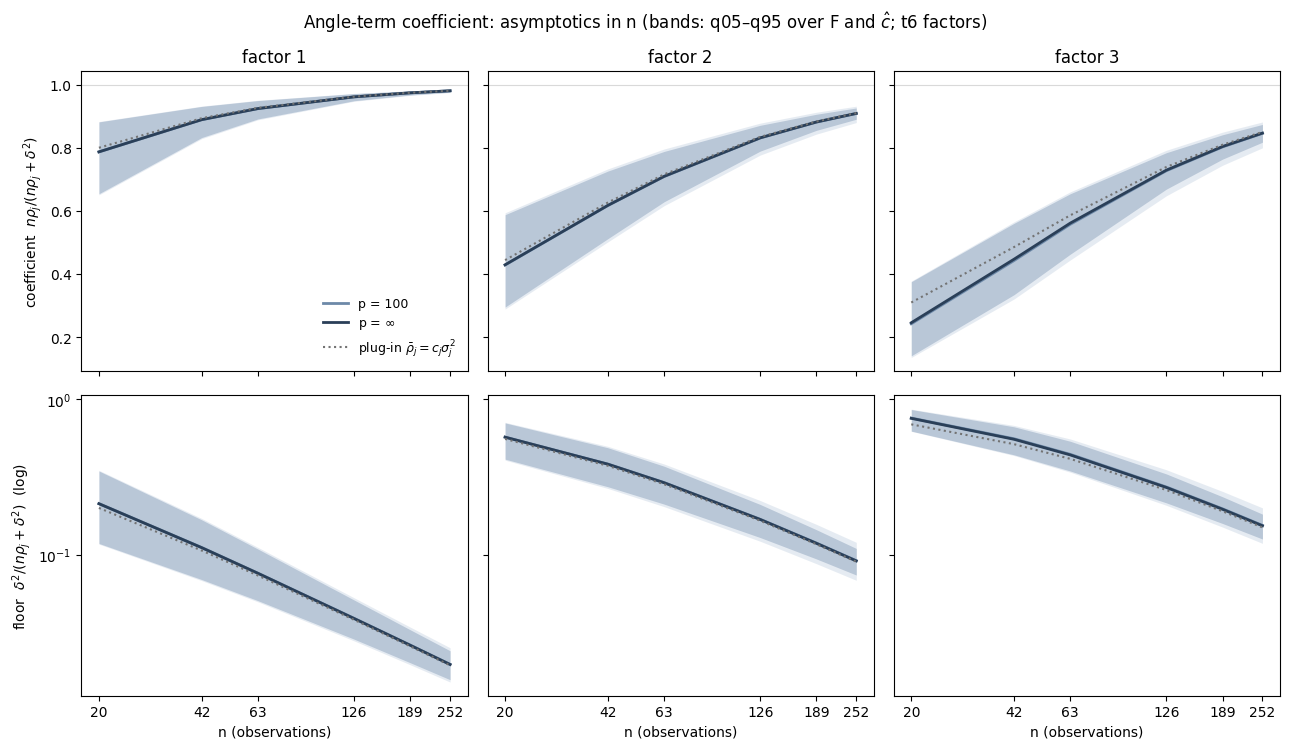

In [52]:
P_LO, P_INF = "#6D89A8", "#2A3F58"        # sequential: light = p=100, dark = p=inf
BAND_LO, BAND_INF = "#ACBFD4", "#54749A"
GUIDE = "0.45"

co = tbl_np[(tbl_np["dist"] == "t6") & (tbl_np["metric"] == "coefficient")]

def coeff_q(pv, lvl, j):
    s = co[(co["p"] == pv) & (co["quantile"] == lvl) & (co["factor"] == j)]
    return s.set_index("n").loc[N_VALUES, "value"].to_numpy()

fig, axes = plt.subplots(2, k, figsize=(13, 7.6), sharex=True, sharey="row")
for j in range(1, k + 1):
    ax = axes[0, j - 1]
    for pv, line_c, band_c, lab in [(100, P_LO, BAND_LO, "p = 100"),
                                    (np.inf, P_INF, BAND_INF, r"p = $\infty$")]:
        ax.fill_between(N_VALUES, coeff_q(pv, 0.05, j), coeff_q(pv, 0.95, j),
                        color=band_c, alpha=0.30, lw=0)
        ax.plot(N_VALUES, coeff_q(pv, 0.50, j), color=line_c, lw=2, label=lab)
    nro = np.array(N_VALUES) * c[j - 1] * sigma[j - 1] ** 2
    ax.plot(N_VALUES, nro / (nro + DELTA2), color=GUIDE, ls=":", lw=1.5,
            label=r"plug-in $\bar\rho_j = c_j\sigma_j^2$")
    ax.axhline(1.0, color="0.85", lw=0.8)
    ax.set_xscale("log"); ax.set_xticks(N_VALUES); ax.set_xticklabels(N_VALUES)
    ax.set_title(f"factor {j}")

    ax = axes[1, j - 1]
    for pv, line_c, band_c in [(100, P_LO, BAND_LO), (np.inf, P_INF, BAND_INF)]:
        ax.fill_between(N_VALUES, 1 - coeff_q(pv, 0.95, j), 1 - coeff_q(pv, 0.05, j),
                        color=band_c, alpha=0.30, lw=0)
        ax.plot(N_VALUES, 1 - coeff_q(pv, 0.50, j), color=line_c, lw=2)
    ax.plot(N_VALUES, DELTA2 / (nro + DELTA2), color=GUIDE, ls=":", lw=1.5)
    ax.set_yscale("log"); ax.set_xlabel("n (observations)")
    ax.minorticks_off()

axes[0, 0].set_ylabel(r"coefficient  $n\rho_j/(n\rho_j+\delta^2)$")
axes[1, 0].set_ylabel(r"floor  $\delta^2/(n\rho_j+\delta^2)$  (log)")
axes[0, 0].legend(frameon=False, fontsize=9, loc="lower right")
fig.suptitle("Angle-term coefficient: asymptotics in n (bands: q05–q95 over F and $\\hat{c}$; t6 factors)",
             y=0.98)
fig.tight_layout()
fig.savefig("nb_outputs/ex4_coeff_vs_n.png", dpi=200, bbox_inches="tight")
plt.show()

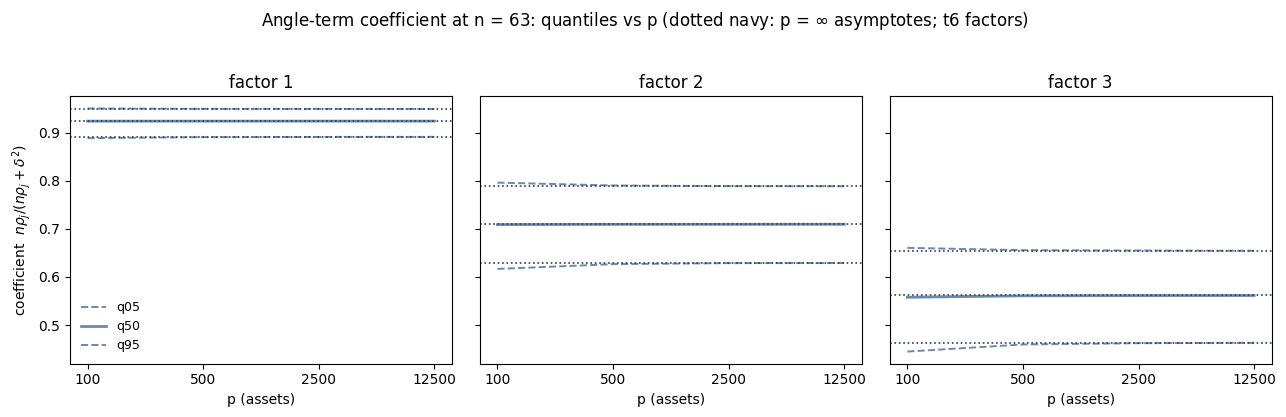

In [53]:
P_FINITE = [100, 500, 2500, 12500]
co63 = co[co["n"] == 63]

fig, axes = plt.subplots(1, k, figsize=(13, 4), sharey=True)
for ax, j in zip(axes, range(1, k + 1)):
    for lvl, ls, lw in [(0.05, "--", 1.4), (0.50, "-", 2.0), (0.95, "--", 1.4)]:
        v = [co63[(co63["p"] == pv) & (co63["quantile"] == lvl)
                  & (co63["factor"] == j)]["value"].item() for pv in P_FINITE]
        ax.plot(P_FINITE, v, ls, color=P_LO, lw=lw,
                label=f"q{int(lvl*100):02d}" if j == 1 else None)
        vinf = co63[(co63["p"] == np.inf) & (co63["quantile"] == lvl)
                    & (co63["factor"] == j)]["value"].item()
        ax.axhline(vinf, color=P_INF, ls=":", lw=1.2)
    ax.set_xscale("log"); ax.set_xticks(P_FINITE); ax.set_xticklabels(P_FINITE)
    ax.minorticks_off()
    ax.set_title(f"factor {j}"); ax.set_xlabel("p (assets)")
axes[0].set_ylabel(r"coefficient  $n\rho_j/(n\rho_j+\delta^2)$")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle(r"Angle-term coefficient at n = 63: quantiles vs p "
             r"(dotted navy: p = $\infty$ asymptotes; t6 factors)", y=1.03)
fig.tight_layout()
fig.savefig("nb_outputs/ex4_coeff_vs_p.png", dpi=200, bbox_inches="tight")
plt.show()

## In-subspace error → 0

In the $p\to\infty$ limit the total error splits into two pieces (eq. (6) / eq. (18)):

$$\sin^2\angle(h_j, \bar b_j) \;\to\; \underbrace{\frac{\delta^2}{n\rho_j+\delta^2}}_{\text{out-of-subspace (floor)}} \;+\; \underbrace{\frac{n\rho_j}{n\rho_j+\delta^2}\,\sin^2\angle(\hat w_j, e_j)}_{\text{in-subspace (weighted rotation)}}$$

Both pieces are functionals of the $n$-sized factor sample $F$ — so neither moves with $p$,
and both vanish only as $n\to\infty$. Everything below uses the *population* prevalences
$C = \mathrm{diag}(c)$: the loadings $B$ are never drawn and nothing is estimated from a
cross-section, so the figure is $p$-free and $B$-free by construction. The plot shows the
in-subspace piece at q50/q80/q95 on log–log axes: every quantile decays to 0 at the $1/n$
rate (dotted guide), for every factor. Top row: t6 factor returns; bottom row: gaussian
factor returns with the same $\sigma_j$ (all axes shared).

The large q95 rotation seen at $n=63$ in the earlier cells is the transient visible here as
the *shoulder* in factors 2 and 3: their population eigenvalues ($c_2\sigma_2^2 = 0.0064$ vs
$c_3\sigma_3^2 = 0.0036$) are so close that until $n$ resolves the gap, a few percent of
sample paths swap/mix the two — and in that regime the q95 even exceeds the floor. Once past
it ($n \gtrsim 126$, i.e. about half a year of daily data), q95 collapses onto the same $1/n$
decay as the median, and the in-subspace error sits well below the floor (dashed) everywhere.
Factor 1, whose eigenvalue is well separated, never has a shoulder. The 2↔3 mixing stays
inside the signal subspace — the leak onto axis 1 equals factor 1's rotation exactly, by
orthogonality — so it is in-subspace error that dies at $1/n$, not error escaping the factor
structure. Note the calendar scale: $n = 504, 1008$ are 2 and 4 years of daily data — those
points are an asymptotic-rate check, not a practical operating regime.

The gaussian row isolates what heavy tails do: the $1/n$ rate and the eventual levels are
identical, but t6 kurtosis inflates the eigenvalue noise and therefore raises and lengthens
the swap shoulder — the heavy-tail penalty lives in the transient, not in the rate.

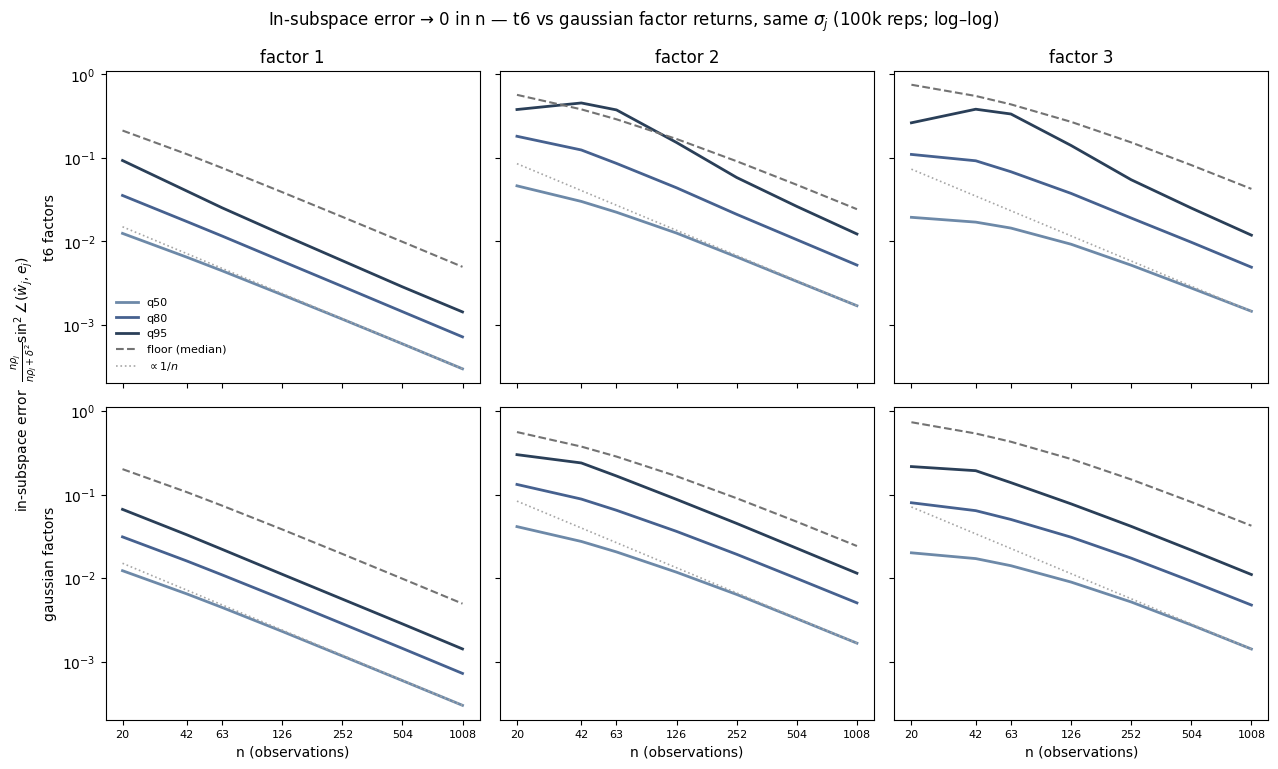

In [54]:
N_EXT = [20, 42, 63, 126, 252, 504, 1008]

rows = []
for d_idx, dist in enumerate(["t6", "normal"]):
    for nv in N_EXT:
        S = sample_second_moments(nv, np.random.default_rng([SEED, nv, d_idx]), dist)
        Dhat = np.sqrt(c)[:, None] * S * np.sqrt(c)[None, :]
        vals, vecs = np.linalg.eigh(Dhat)
        rhos = vals[:, ::-1]; W = vecs[:, :, ::-1]
        rot = 1.0 - np.diagonal(W ** 2, axis1=1, axis2=2)
        ws = (nv * rhos / (nv * rhos + DELTA2)) * rot
        fl = DELTA2 / (nv * rhos + DELTA2)
        for j in range(k):
            rec = {"dist": dist, "n": nv, "factor": j + 1,
                   "floor_q50": np.median(fl[:, j])}
            for lvl in [0.50, 0.80, 0.95]:
                rec[f"q{int(lvl*100)}"] = np.quantile(ws[:, j], lvl)
            rows.append(rec)

tbl_ins = pd.DataFrame(rows)
tbl_ins.to_csv("nb_outputs/ex4_insubspace_decay.csv", index=False)

C_Q = {"q50": "#6D89A8", "q80": "#46618F", "q95": "#2A3F58"}
fig, axes = plt.subplots(2, k, figsize=(13, 7.8), sharex=True, sharey=True)
for r, dist in enumerate(["t6", "normal"]):
    for ax, j in zip(axes[r], range(1, k + 1)):
        sub = (tbl_ins[(tbl_ins["dist"] == dist) & (tbl_ins["factor"] == j)]
               .set_index("n").loc[N_EXT])
        for qn, col in C_Q.items():
            ax.plot(N_EXT, sub[qn], color=col, lw=2,
                    label=qn if (r, j) == (0, 1) else None)
        ax.plot(N_EXT, sub["floor_q50"], color="0.45", ls="--", lw=1.5,
                label="floor (median)" if (r, j) == (0, 1) else None)
        guide = sub["q50"].iloc[-1] * (N_EXT[-1] / np.array(N_EXT))
        ax.plot(N_EXT, guide, color="0.65", ls=":", lw=1.2,
                label=r"$\propto 1/n$" if (r, j) == (0, 1) else None)
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xticks(N_EXT); ax.set_xticklabels(N_EXT, fontsize=8)
        ax.minorticks_off()
        if r == 0:
            ax.set_title(f"factor {j}")
        else:
            ax.set_xlabel("n (observations)")
    axes[r, 0].set_ylabel("t6 factors" if dist == "t6" else "gaussian factors")
fig.supylabel(r"in-subspace error  $\frac{n\rho_j}{n\rho_j+\delta^2}\sin^2\angle(\hat w_j, e_j)$",
              fontsize=10)
axes[0, 0].legend(frameon=False, fontsize=8, loc="lower left")
fig.suptitle("In-subspace error → 0 in n — t6 vs gaussian factor returns, same $\\sigma_j$ "
             "(100k reps; log–log)", y=0.98)
fig.tight_layout()
fig.savefig("nb_outputs/ex4_insubspace_decay.png", dpi=200, bbox_inches="tight")
plt.show()

## A realistic 6-factor calibration

Annualized vols in the style of a US equity model — one dominant market factor, a tight
mid cluster of styles, and a weak pair:

| $j$ | analogue | $\sigma_j$ (ann.) | $c_j$ | $\rho_j = c_j\sigma_j^2$ | gap to next |
|---|---|---|---|---|---|
| 1 | market | 16% | 1.25 | 0.0320 | 3.2× |
| 2 | momentum | 10% | 1 | 0.0100 | 1.23× |
| 3 | value | 9% | 1 | 0.0081 | 1.27× |
| 4 | size | 8% | 1 | 0.0064 | 1.78× |
| 5 | quality | 6% | 1 | 0.0036 | 1.44× |
| 6 | investment | 5% | 1 | 0.0025 | — |

with $\delta = 0.40$ annualized idio vol, as in the canonical model. Units note: using
annualized numbers per-period with $n$ in trading days is *exactly* the daily-scaled model —
every quantity here depends only on eigenvalue ratios and $n\rho_j/\delta^2$, and the 1/252
cancels from both $\rho_j$ and $\delta^2$.

Findings (t6 factors; details in the cells below):

- **Per-factor identification inside the style cluster fails at practical horizons.** At
  $n=63$ the mid-cluster rotations have medians 0.29–0.58 and q95 ≈ 0.99; at $n=252$ the
  q95 is still 0.88–0.97; even $n=1008$ (4 years) leaves factor 3 at q95 ≈ 0.29. Unlike the
  k=3 case, the weighted in-subspace error *exceeds the floor at the median* for factors
  2–3 at both a quarter and a year — with realistic style spacing (gap ratios 1.2–1.3),
  the "rotation is subdominant" claim does not hold per-factor.
- **The estimable objects are the blocks.** Factor 1 is clean at all $n$ (q95 = 0.09 at a
  quarter). The block subspace errors (largest principal angle) of {2,3,4} and {5,6} decay
  at $1/n$ and are small by a year (q95 ≈ 0.09 at $n=252$) — though at a quarter even the
  blocks are marginal (q95 ≈ 0.78), because the block boundary between size and quality
  carries the same 1.78 eigenvalue ratio that produced the k=3 shoulder. The coarse split
  {market} ⊕ {styles} is always clean: the styles-block leak onto axis 1 equals factor 1's
  rotation identically.

So with more factors the k=3 message sharpens into a hierarchy of identifiability:
market always; blocks after ~a year; individual clustered styles effectively never within
stationary daily-data horizons.

In [55]:
K6 = 6
SIG6 = np.array([0.16, 0.10, 0.09, 0.08, 0.06, 0.05])
C6 = np.array([1.25, 1, 1, 1, 1, 1.0])
BLOCKS6 = {"market": [0], "styles {2,3,4}": [1, 2, 3], "weak pair {5,6}": [4, 5]}
CHUNK6 = 5_000
Q6 = [0.05, 0.25, 0.50, 0.75, 0.80, 0.95]   # box (q25/q50/q75) + whiskers (q05/q95)

def block_sin2max(W, cols):
    """Largest principal angle sin^2 between span(W[:, cols]) and span(e_cols)."""
    comp = [a for a in range(K6) if a not in cols]
    M = W[:, comp][:, :, cols]                      # (reps, |comp|, |cols|)
    s = np.linalg.svd(M, compute_uv=False)
    return np.clip(s[:, 0] ** 2, 0.0, 1.0)

rows = []
for d_idx, dist in enumerate(["t6", "normal"]):
    for nv in N_EXT:
        rng6 = np.random.default_rng([SEED, nv, d_idx, K6])
        rot = np.empty((N_REPS, K6)); ws = np.empty((N_REPS, K6)); fl = np.empty((N_REPS, K6))
        blk = {b: np.empty(N_REPS) for b in BLOCKS6}
        for i0 in range(0, N_REPS, CHUNK6):
            if dist == "t6":
                F = rng6.standard_t(6, size=(CHUNK6, nv, K6)) / np.sqrt(1.5) * SIG6
            else:
                F = rng6.standard_normal(size=(CHUNK6, nv, K6)) * SIG6
            X = F * np.sqrt(C6)
            Dh = np.einsum("rni,rnj->rij", X, X) / nv
            vals, vecs = np.linalg.eigh(Dh)
            rhos = vals[:, ::-1]; W = vecs[:, :, ::-1]
            r = 1.0 - np.diagonal(W ** 2, axis1=1, axis2=2)
            rot[i0:i0+CHUNK6] = r
            ws[i0:i0+CHUNK6] = (nv * rhos / (nv * rhos + DELTA2)) * r
            fl[i0:i0+CHUNK6] = DELTA2 / (nv * rhos + DELTA2)
            for b, cols in BLOCKS6.items():
                blk[b][i0:i0+CHUNK6] = block_sin2max(W, cols)
        for j in range(K6):
            for lvl in Q6:
                rows.append({"dist": dist, "n": nv, "series": f"factor {j+1}",
                             "metric": "rotation", "quantile": lvl,
                             "value": np.quantile(rot[:, j], lvl)})
                rows.append({"dist": dist, "n": nv, "series": f"factor {j+1}",
                             "metric": "weighted_rotation", "quantile": lvl,
                             "value": np.quantile(ws[:, j], lvl)})
            rows.append({"dist": dist, "n": nv, "series": f"factor {j+1}",
                         "metric": "floor", "quantile": 0.50,
                         "value": np.median(fl[:, j])})
        for b in BLOCKS6:
            for lvl in Q6:
                rows.append({"dist": dist, "n": nv, "series": b,
                             "metric": "block_sin2max", "quantile": lvl,
                             "value": np.quantile(blk[b], lvl)})

tbl_k6 = pd.DataFrame(rows)
tbl_k6.to_csv("nb_outputs/ex4_k6_quantiles.csv", index=False)
tbl_k6[(tbl_k6["dist"] == "t6") & (tbl_k6["n"] == 63)
       & (tbl_k6["metric"] == "rotation")
       & (tbl_k6["quantile"].isin([0.50, 0.80, 0.95]))].pivot(
    index="quantile", columns="series", values="value").round(3)

series,factor 1,factor 2,factor 3,factor 4,factor 5,factor 6
quantile,,,,,,
0.50,0.022,0.287,0.576,0.408,0.236,0.113
0.80,0.046,0.822,0.932,0.858,0.651,0.437
0.95,0.093,0.990,0.996,0.992,0.971,0.942


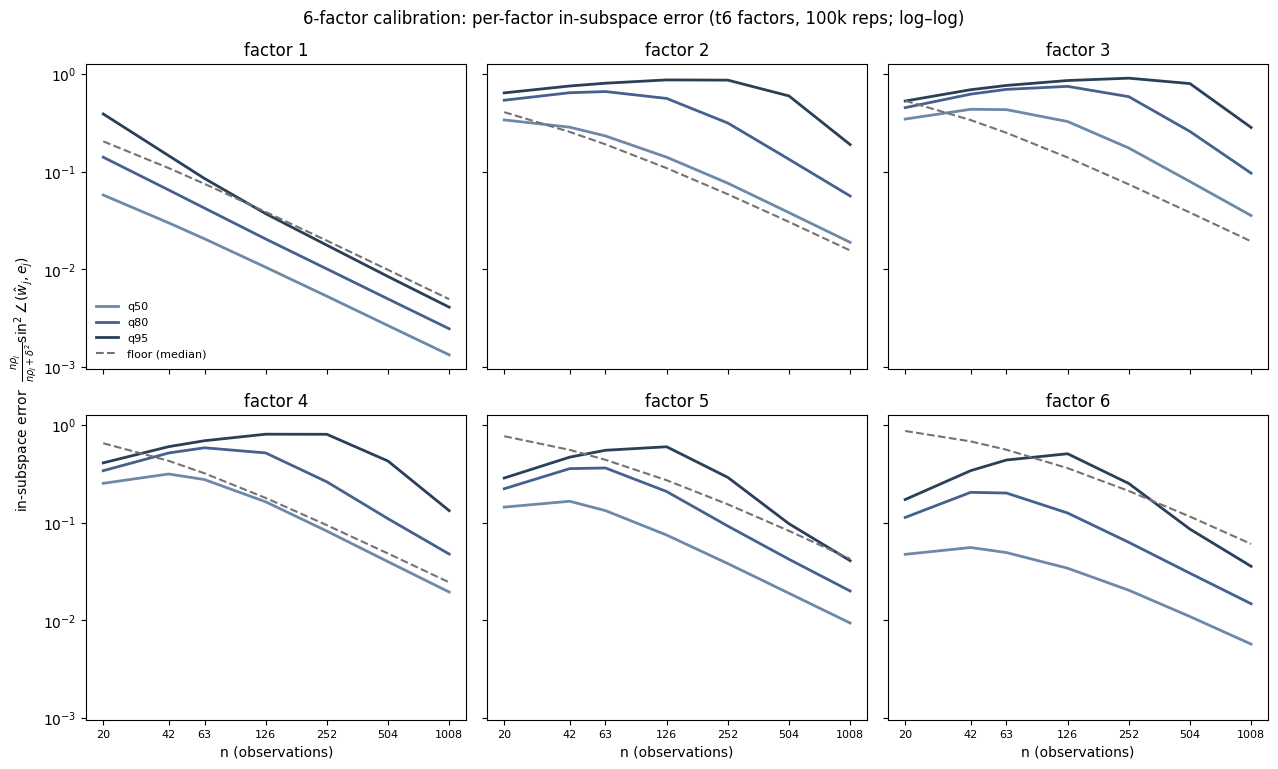

In [59]:
k6t = tbl_k6[tbl_k6["dist"] == "t6"]

def k6_q(series, metric, lvl):
    s = k6t[(k6t["series"] == series) & (k6t["metric"] == metric)
            & (k6t["quantile"] == lvl)]
    return s.set_index("n").loc[N_EXT, "value"].to_numpy()

FLABELS = ["market", "momentum", "value", "size", "quality", "investment"]
FLABELS = ["market", "momentum", "value", "size", "quality", "investment"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7.8), sharex=True, sharey=True)
for j, ax in enumerate(axes.ravel(), start=1):
    for qn, col in C_Q.items():
        ax.plot(N_EXT, k6_q(f"factor {j}", "weighted_rotation", float(qn[1:]) / 100),
                color=col, lw=2, label=qn if j == 1 else None)
    ax.plot(N_EXT, k6_q(f"factor {j}", "floor", 0.50), color="0.45", ls="--", lw=1.5,
            label="floor (median)" if j == 1 else None)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xticks(N_EXT); ax.set_xticklabels(N_EXT, fontsize=8)
    ax.minorticks_off()
#     ax.set_title(f"factor {j} ({FLABELS[j-1]})")
    ax.set_title(f"factor {j}")

    if j > 3:
        ax.set_xlabel("n (observations)")
fig.supylabel(r"in-subspace error  $\frac{n\rho_j}{n\rho_j+\delta^2}\sin^2\angle(\hat w_j, e_j)$",
              fontsize=10)
axes[0, 0].legend(frameon=False, fontsize=8, loc="lower left")
fig.suptitle("6-factor calibration: per-factor in-subspace error (t6 factors, 100k reps; log–log)",
             y=0.98)
fig.tight_layout()
fig.savefig("nb_outputs/ex4_k6_perfactor.png", dpi=200, bbox_inches="tight")
plt.show()

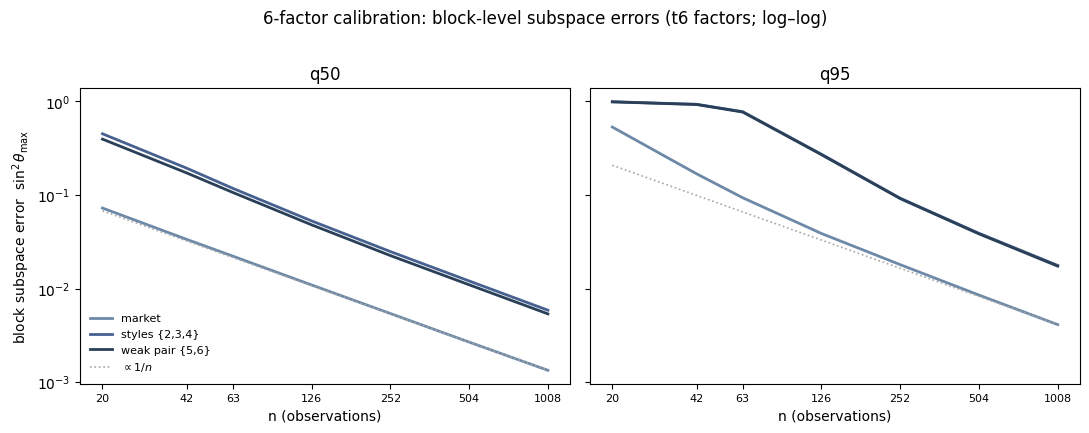

In [57]:
BLOCK_COLORS = {"market": "#6D89A8", "styles {2,3,4}": "#46618F", "weak pair {5,6}": "#2A3F58"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)
for ax, lvl in zip(axes, [0.50, 0.95]):
    for b, col in BLOCK_COLORS.items():
        ax.plot(N_EXT, k6_q(b, "block_sin2max", lvl), color=col, lw=2,
                label=b if lvl == 0.50 else None)
    guide = k6_q("market", "block_sin2max", lvl)[-1] * (N_EXT[-1] / np.array(N_EXT))
    ax.plot(N_EXT, guide, color="0.65", ls=":", lw=1.2,
            label=r"$\propto 1/n$" if lvl == 0.50 else None)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xticks(N_EXT); ax.set_xticklabels(N_EXT, fontsize=8)
    ax.minorticks_off()
    ax.set_title(f"q{int(lvl*100)}"); ax.set_xlabel("n (observations)")
axes[0].set_ylabel(r"block subspace error  $\sin^2\theta_{\max}$")
axes[0].legend(frameon=False, fontsize=8, loc="lower left")
fig.suptitle("6-factor calibration: block-level subspace errors (t6 factors; log–log)", y=1.02)
fig.tight_layout()
fig.savefig("nb_outputs/ex4_k6_blocks.png", dpi=200, bbox_inches="tight")
plt.show()

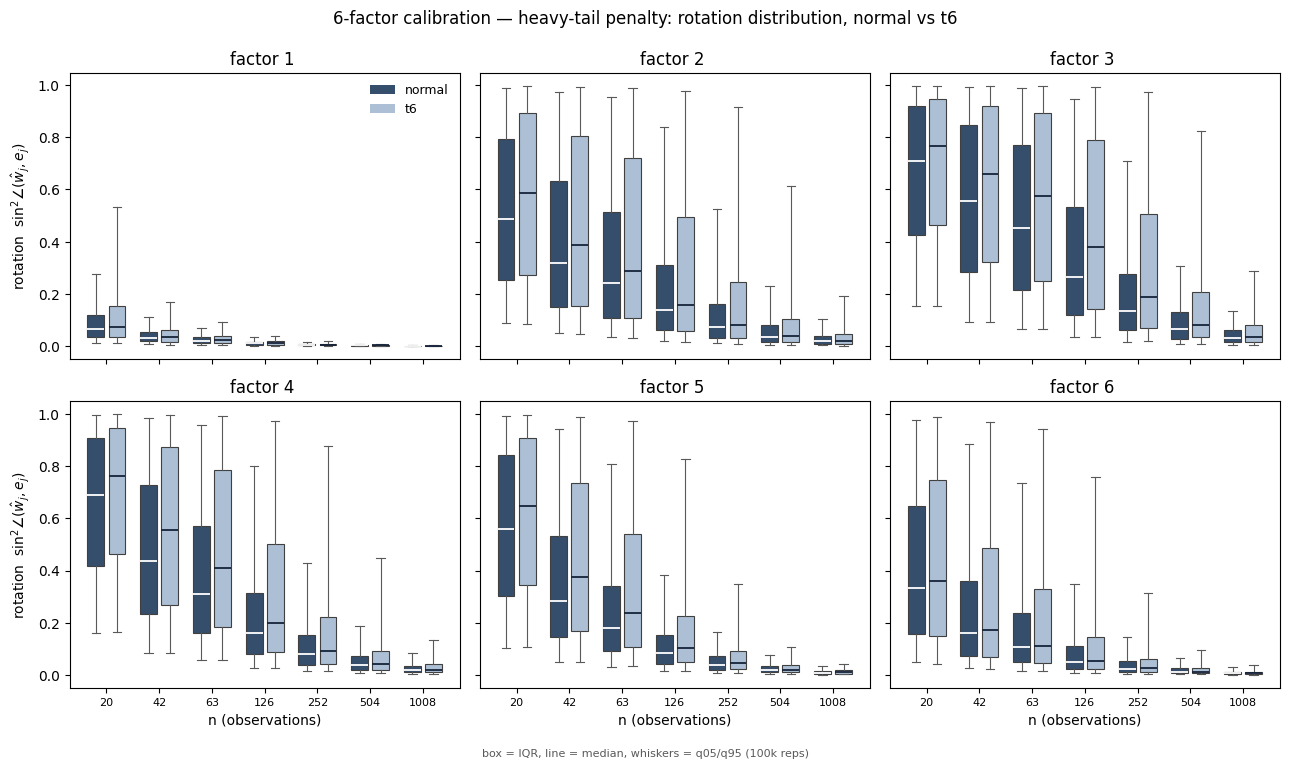

In [60]:
rot6 = tbl_k6[tbl_k6["metric"] == "rotation"]

x6 = np.arange(len(N_EXT))
fig, axes = plt.subplots(2, 3, figsize=(13, 7.4), sharex=True, sharey=True)
for j, ax in enumerate(axes.ravel(), start=1):
    for dist, fc, off, mc in [("normal", NORMAL, -0.2, "white"), ("t6", T6, 0.2, "#16233A")]:
        sub = (rot6[(rot6["dist"] == dist) & (rot6["series"] == f"factor {j}")]
               .pivot(index="n", columns="quantile", values="value").loc[N_EXT])
        rotation_bxp(ax, sub, x6 + off, fc, mc)
    # ax.set_title(f"factor {j} ({FLABELS[j-1]})")
    ax.set_title(f"factor {j} ")

    ax.set_xticks(x6); ax.set_xticklabels(N_EXT, fontsize=8)
    if j > 3:
        ax.set_xlabel("n (observations)")
for ax in axes[:, 0]:
    ax.set_ylabel(r"rotation  sin$^2\angle(\hat w_j, e_j)$")
axes[0, 0].legend(handles=[Patch(facecolor=NORMAL, label="normal"),
                           Patch(facecolor=T6, label="t6")], frameon=False, fontsize=9)
fig.suptitle("6-factor calibration — heavy-tail penalty: rotation distribution, normal vs t6",
             y=0.99)
fig.text(0.5, -0.02, "box = IQR, line = median, whiskers = q05/q95 (100k reps)",
         ha="center", fontsize=8, color="0.35")
fig.tight_layout()
fig.savefig("nb_outputs/ex4_k6_rotation_boxplots.png", dpi=200, bbox_inches="tight")
plt.show()